# Runs aral sea model using PCR input

In [1]:
# setup imports
import sys
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import xarray as xr

import importlib
import src.aral as aral
importlib.reload(aral)

from src.constants import STATIONS_PCR

from src.paths import GRDC
from ewatercycle.observation.grdc import get_grdc_data


In [2]:
from src.constants import MAKKINK_FACTOR
print(f"Makkink correction factor: {MAKKINK_FACTOR}")

Makkink correction factor: 1.0


In [3]:
import xarray as xr

ds = xr.open_dataset("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/pcrglobwb/aral_discharge_master.nc")
print(ds)

importlib.reload(aral)

nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")

<xarray.Dataset> Size: 53MB
Dimensions:     (simulation: 9, time: 29586, station: 50)
Coordinates:
  * simulation  (simulation) <U47 2kB 'era5_default' ... 'cmip_mri-esm2_raw_p...
  * time        (time) datetime64[ns] 237kB 1940-01-01 1940-01-02 ... 2020-12-31
    lat         (station) float32 200B ...
    lon         (station) float32 200B ...
  * station     (station) <U14 3kB 'Tyumen-aryk' 'Kazalinsk' ... 'Obizarang'
Data variables:
    discharge   (simulation, time, station) float32 53MB ...


In [4]:
ds.simulation.values

array(['era5_default', 'era5_chatly', 'era5_kazalinsk',
       'era5_uncalibrated', 'cmip_hist_miroc6',
       'cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs',
       'cmip_mpi_esm1_2_hr_raw_parallel_runs',
       'cmip_mri-esm2_bias_corrected_parallel_runs',
       'cmip_mri-esm2_raw_parallel_runs'], dtype='<U47')

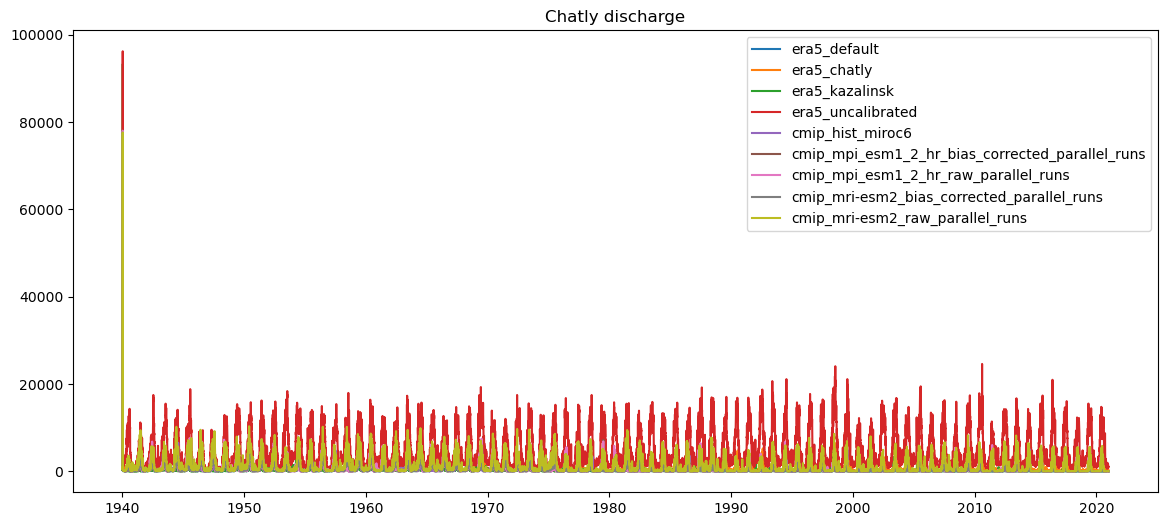

In [5]:
import matplotlib.pyplot as plt

da = ds["discharge"]

plt.figure(figsize=(14,6))

for sim_name in da.simulation.values:
    series = da.sel(simulation=sim_name, station="Chatly")

    plt.plot(series.time, series.values, label=sim_name)

plt.title("Chatly discharge")
plt.legend()
plt.show()

In [6]:
rivers = {}

for sim_name in da.simulation.values:

    rivers[sim_name] = {
        "Amu": aral.River(
            da.sel(simulation=sim_name, station="Chatly"),
            name=f"Amu - {sim_name}"
        ),
        "Syr": aral.River(
            da.sel(simulation=sim_name, station="Kazalinsk"),
            name=f"Syr - {sim_name}"
        )
    }

rivers["era5_river_specific_combined"] = {
    "Amu": rivers["era5_chatly"]["Amu"],
    "Syr": rivers["era5_default"]["Syr"]
}

In [7]:
# rivers["era5_kazalinsk"]["Syr"].Q

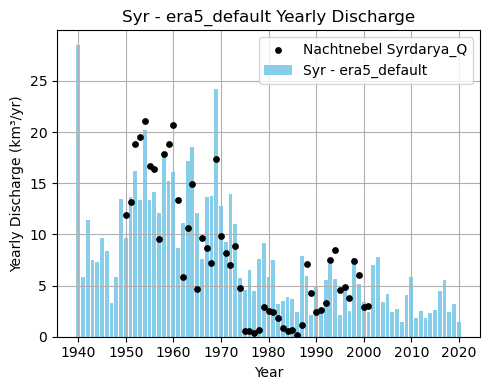

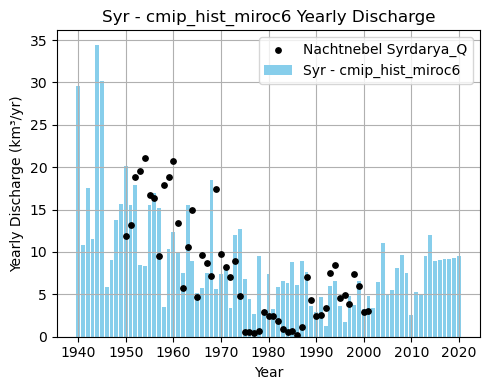

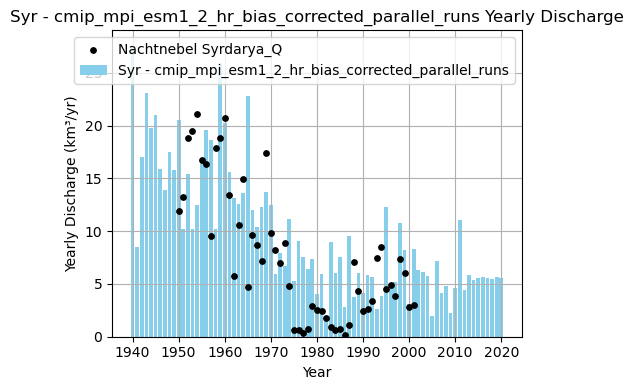

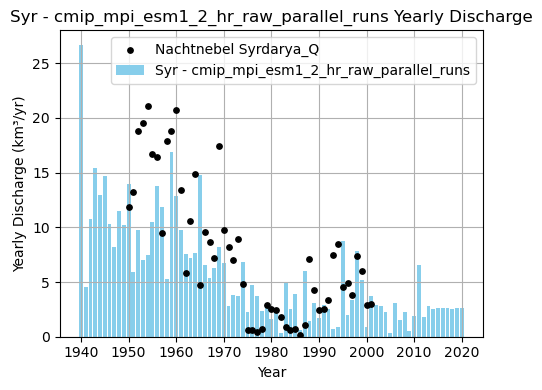

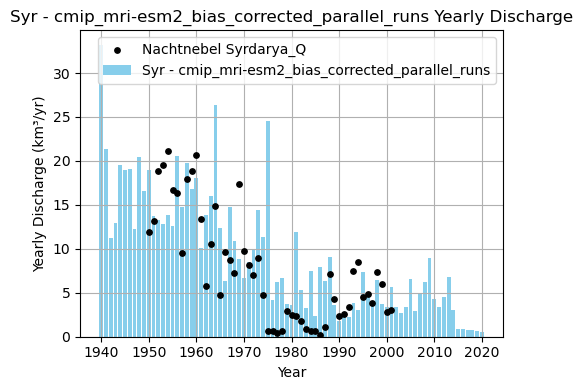

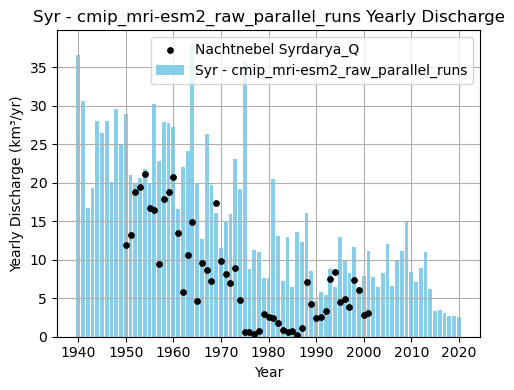

In [8]:
rivers["era5_default"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_hist_miroc6"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mpi_esm1_2_hr_raw_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mri-esm2_bias_corrected_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)

rivers["cmip_mri-esm2_raw_parallel_runs"]["Syr"].plot_yearly(
    observations=nachtnebel["Syrdarya_Q"],
    observation_label="Nachtnebel Syrdarya_Q",
)


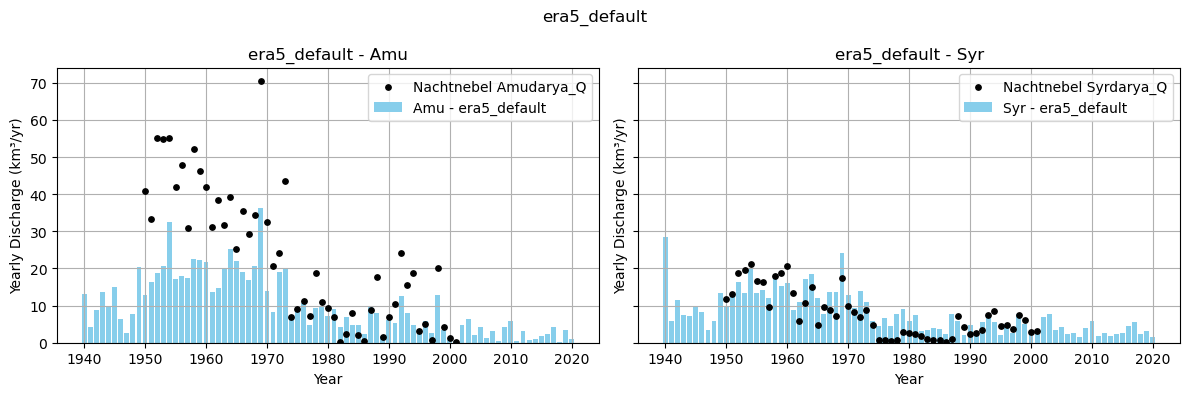

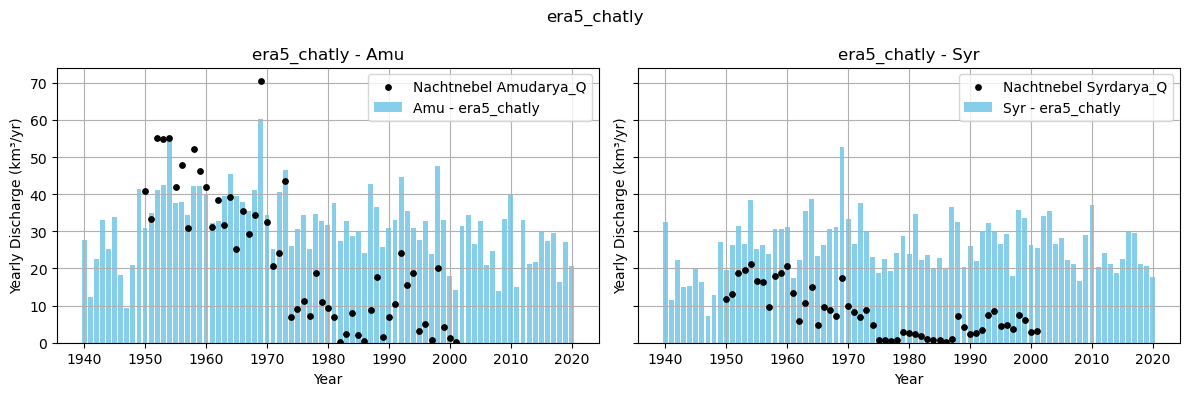

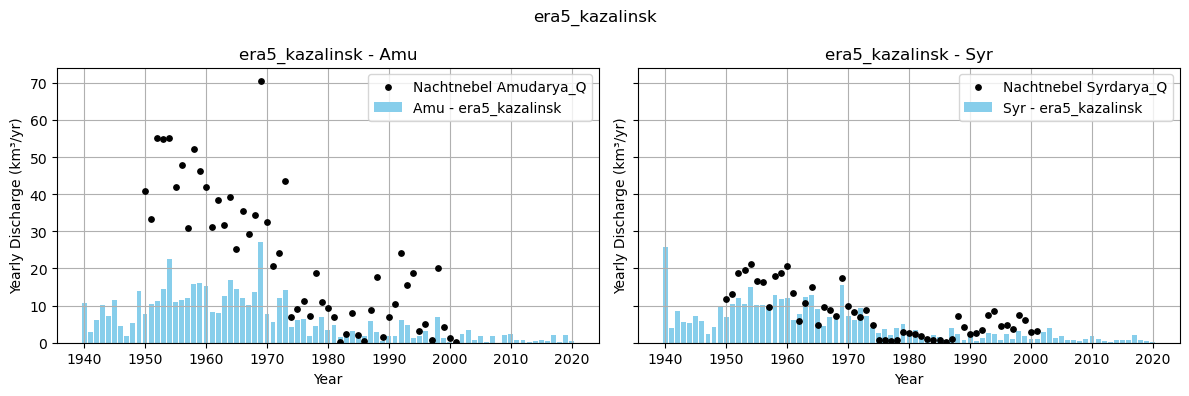

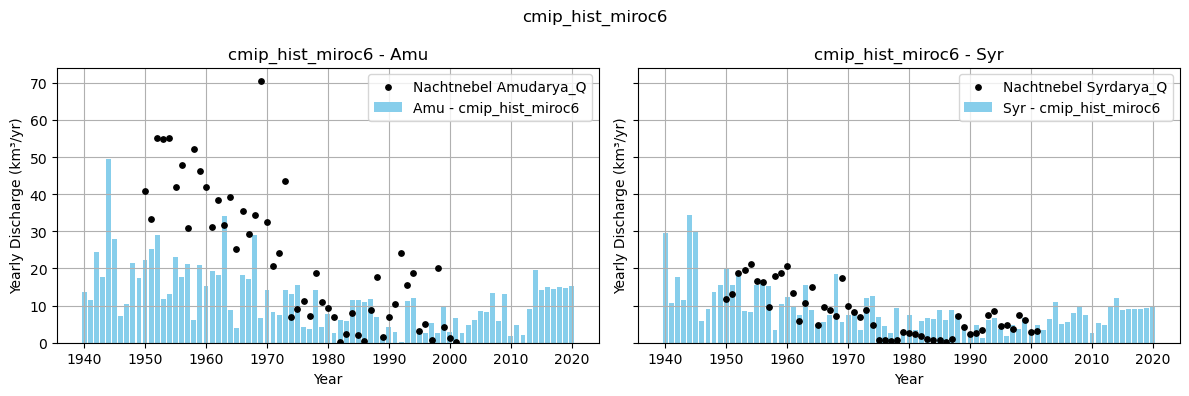

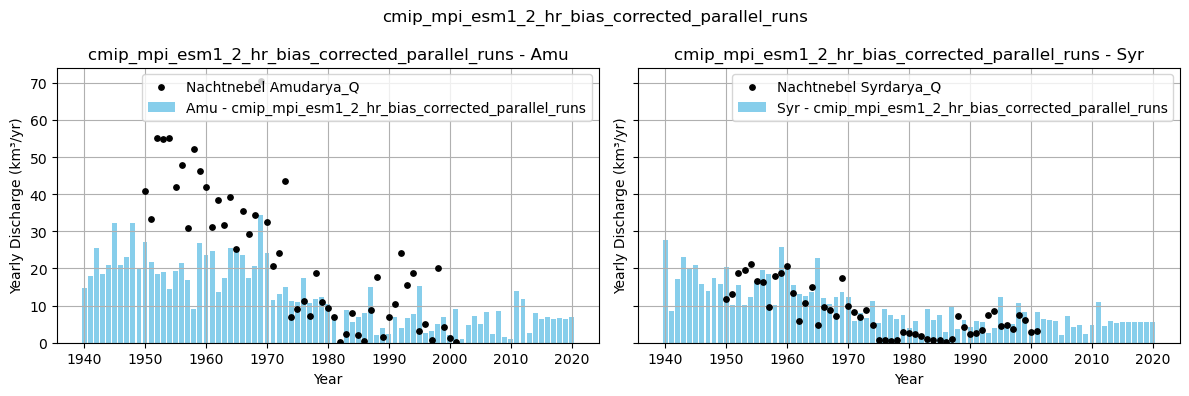

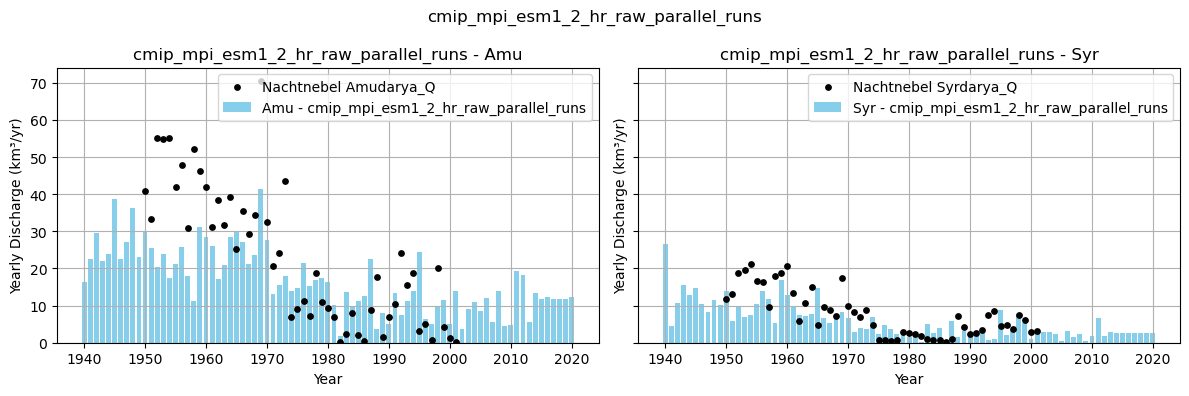

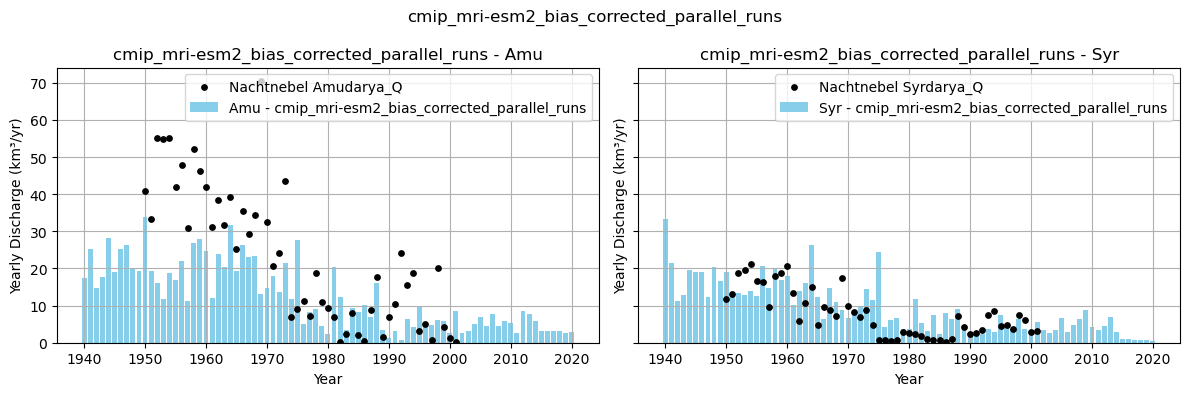

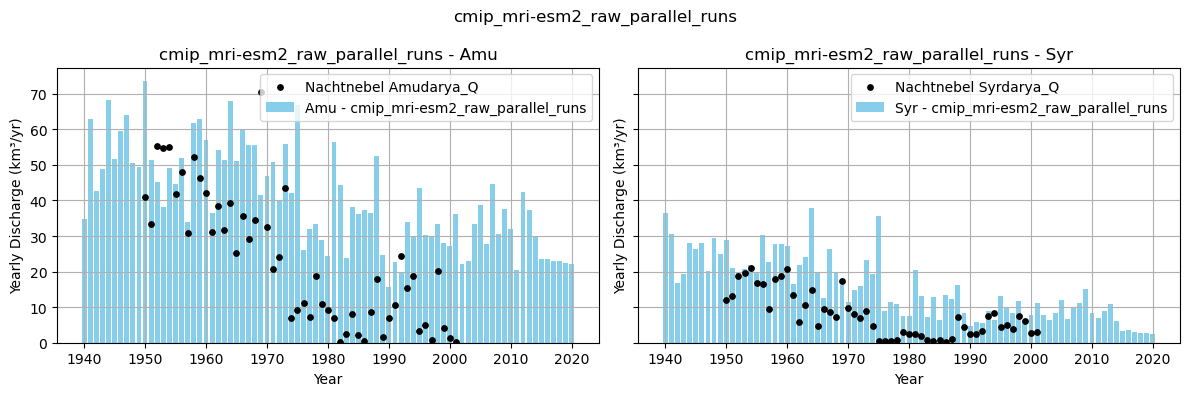

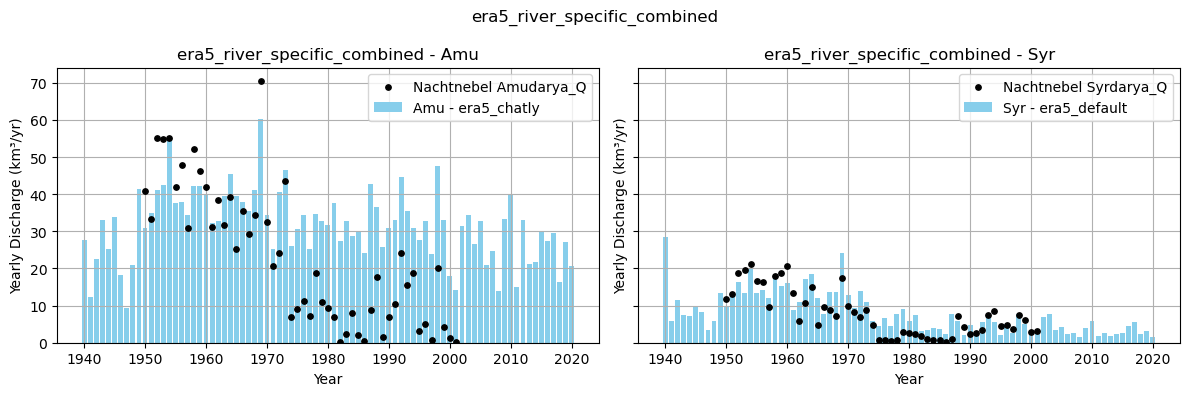

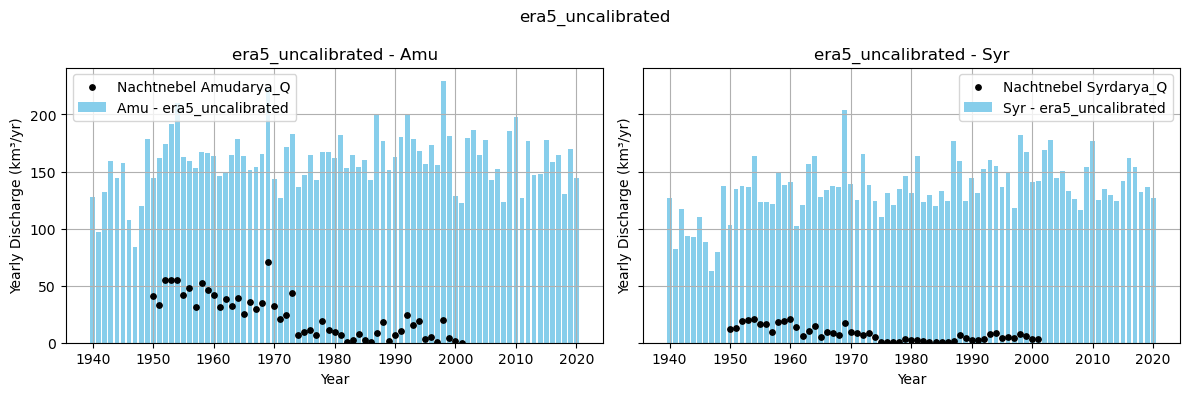

In [10]:
models = [
    "era5_default",
    "era5_chatly",
    "era5_kazalinsk",
    "cmip_hist_miroc6",
    "cmip_mpi_esm1_2_hr_bias_corrected_parallel_runs",
    "cmip_mpi_esm1_2_hr_raw_parallel_runs",
    "cmip_mri-esm2_bias_corrected_parallel_runs",
    "cmip_mri-esm2_raw_parallel_runs",
    "era5_river_specific_combined",
    "era5_uncalibrated",
]


def plot_all(models):
    for m in models:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

        rivers[m]["Amu"].plot_yearly(
            ax=axes[0],
            observations=nachtnebel["Amudarya_Q"],
            observation_label="Nachtnebel Amudarya_Q",
        )
        axes[0].set_title(f"{m} - Amu")

        rivers[m]["Syr"].plot_yearly(
            ax=axes[1],
            observations=nachtnebel["Syrdarya_Q"],
            observation_label="Nachtnebel Syrdarya_Q",
        )
        axes[1].set_title(f"{m} - Syr")

        fig.suptitle(m)
        plt.tight_layout()
        plt.show()

plot_all(models)

In [12]:
# rivers["era5_default"]["Amu"].plot_yearly(
#     observations=nachtnebel["Amudarya_Q"],
#     observation_label="Nachtnebel Amudarya_Q",
# )

In [13]:
rivers["era5_default"]["Amu"].Q_raw

time
1940-01-01    891.125916
1940-01-02    743.249207
1940-01-03    439.481079
1940-01-04    403.749298
1940-01-05    418.183746
                 ...    
2020-12-27      4.652431
2020-12-28      4.231482
2020-12-29      3.427431
2020-12-30      3.952060
2020-12-31      4.140590
Name: discharge, Length: 29586, dtype: float32

In [14]:
# # Build one combined dataframe indexed by date
# df_i = df.copy()
# df_cmip_i = df_cmip.copy()

# df_i.index = pd.to_datetime(df_i.index)
# df_cmip_i.index = pd.to_datetime(df_cmip_i.index)

# df_combined = pd.concat(
#     {"era5": df_i, "cmip": df_cmip_i},
#     axis=1,
# ).sort_index()

# print(f"df_combined shape: {df_combined.shape}")
# print(f"period: {df_combined.index.min()} -> {df_combined.index.max()}")
# df_combined.head()

In [15]:
grdc_station_chatly = get_grdc_data(
    2817100, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)
grdc_station_kerki = get_grdc_data(
    2617110, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)

In [16]:
grdc_station_kazalinsk = get_grdc_data(
    2316201, "1940-01-02T00:00Z", "2020-12-31T00:00Z", data_home=GRDC / "Daily"
)

In [17]:
grdc_station_chatly

<xarray.Dataset> Size: 199kB
Dimensions:              (time: 12418)
Coordinates:
  * time                 (time) datetime64[ns] 99kB 1940-01-02 ... 1973-12-31
    id                   int64 8B 2817100
Data variables:
    streamflow           (time) float64 99kB 494.0 494.0 470.0 ... 153.0 158.0
    area                 float64 8B 4.5e+05
    country              <U2 8B 'UZ'
    geo_x                float64 8B 59.7
    geo_y                float64 8B 42.28
    geo_z                float64 8B 72.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U6 24B 'CHATLY'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2817100_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

In [18]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day

rolled_rivers = {}

for sim, rivers_dict in rivers.items():
    rolled_rivers[sim] = {}

    for river_name, river_obj in rivers_dict.items():

        series = river_obj.Q_raw

        rolled = (
            series
            .rolling(window=window_days, min_periods=min_periods)
            .sum()
            * conversion_factor
        )

        rolled.name = f"{river_name}_{sim}"

        rolled_rivers[sim][river_name] = rolled

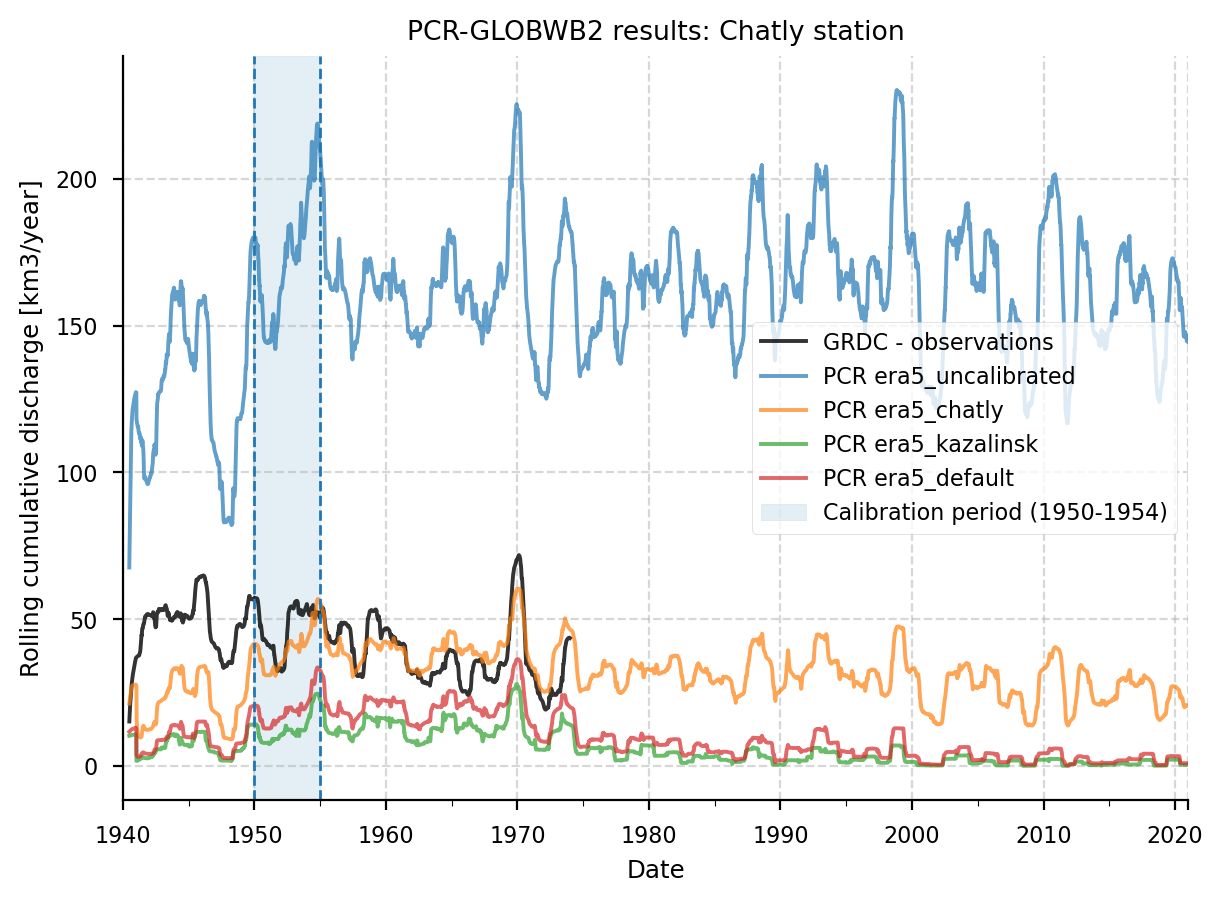

In [24]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day
grdc_station_chatly_roll_cum = (
    conversion_factor
    * grdc_station_chatly["streamflow"].rolling(time=window_days, min_periods=min_periods).sum().to_series()
)


station_name_chatly = "Chatly"
river_chatly1 = aral.River(da.sel(simulation="era5_uncalibrated", station=station_name_chatly))
river_chatly2 = aral.River(da.sel(simulation="era5_chatly", station=station_name_chatly))
river_chatly3 = aral.River(da.sel(simulation="era5_kazalinsk", station=station_name_chatly))
river_chatly4 = aral.River(da.sel(simulation="era5_default", station=station_name_chatly))

riv1 = river_chatly1.Q_raw.rolling(window=window_days, min_periods=min_periods).sum() * conversion_factor
riv2 = river_chatly2.Q_raw.rolling(window=window_days, min_periods=min_periods).sum() * conversion_factor
riv3 = river_chatly3.Q_raw.rolling(window=window_days, min_periods=min_periods).sum() * conversion_factor
riv4 = river_chatly4.Q_raw.rolling(window=window_days, min_periods=min_periods).sum() * conversion_factor

# chatly_era5_roll_cum = conversion_factor * df_combined[("era5", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_cmip_roll_cum = conversion_factor * df_combined[("cmip", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_no_agri_roll_cum = conversion_factor * df_no_agri["Chatly"].rolling(window=window_days, min_periods=min_periods).sum()

cal_start = pd.Timestamp("1950-01-01")
cal_end = pd.Timestamp("1954-12-31")

plt.style.use("seaborn-v0_8-paper")
plt.figure(figsize = (6.0, 4.4), constrained_layout=True, dpi=200) #, fontsize="small")
#plt.style.use("seaborn-v0_8-paper")
grdc_station_chatly_roll_cum.plot(label="GRDC - observations", color="black", alpha=0.8)
riv1.plot( color="tab:blue", alpha=0.7, label="PCR era5_uncalibrated")
riv2.plot( color="tab:orange", alpha=0.7, label="PCR era5_chatly")
riv3.plot( color="tab:green", alpha=0.7, label="PCR era5_kazalinsk")
riv4.plot( color="tab:red", alpha=0.7, label="PCR era5_default")


plt.axvspan(cal_start, cal_end, color="tab:blue", alpha=0.12, label=f"Calibration period ({cal_start.year}-{cal_end.year})")
plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)
plt.title(f"PCR-GLOBWB2 results: {station_name_chatly} station") # rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc = "center right",)
plt.grid(alpha=0.5, linestyle="--")
# plt    "font.size": 9,
#     "axes.labelsize": 9,
#     "axes.titlesize": 9,

plt.show()
#plt.tight_layout()

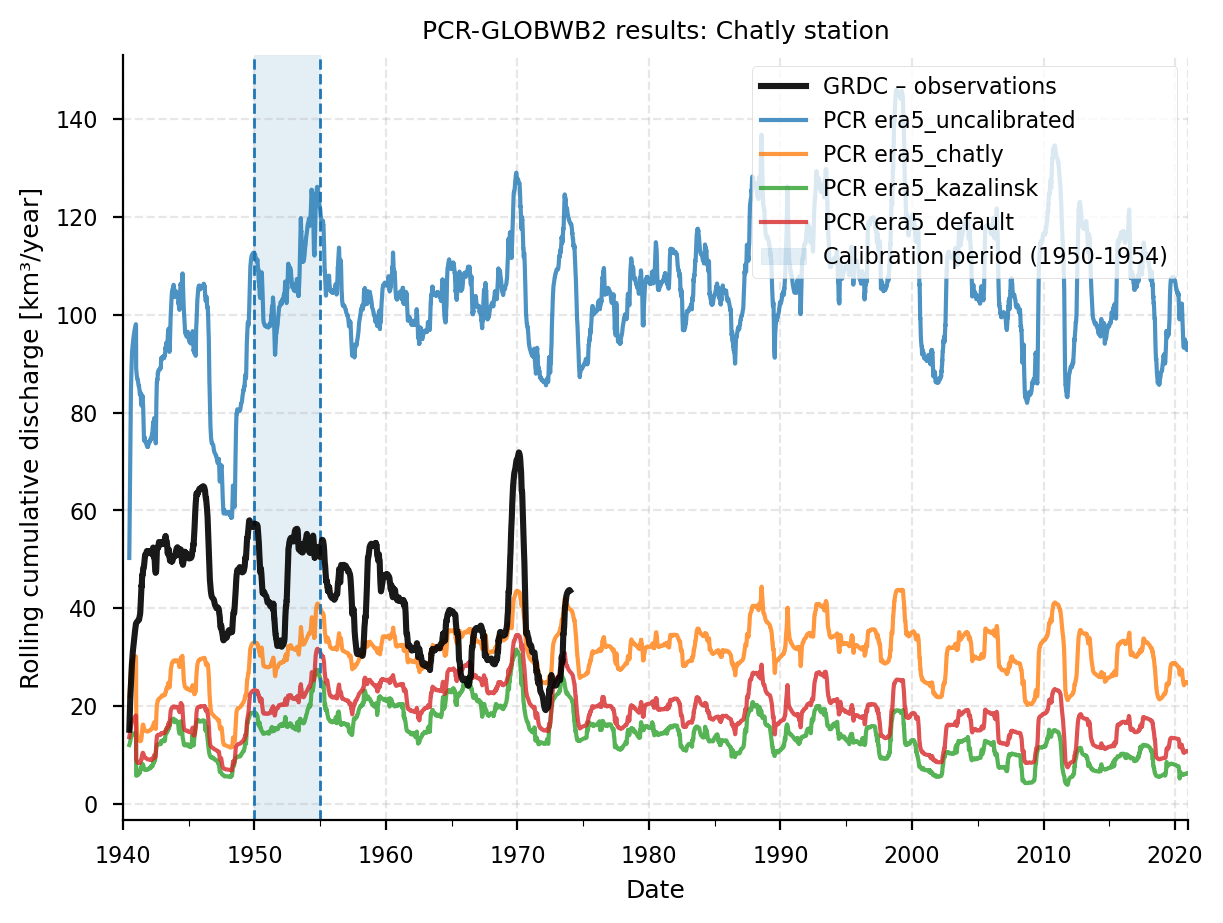

In [23]:
import matplotlib.pyplot as plt

# ---- STYLE (set BEFORE plotting) ----
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---- FIGURE ----
plt.figure(figsize=(6, 4.5), constrained_layout=True, dpi=200)

# observations (make visually dominant)
grdc_station_chatly_roll_cum.plot(
    label="GRDC – observations",
    color="black",
    linewidth=2.2,
    alpha=0.9,
    zorder=10,
)

# model runs
riv1.plot(color="tab:blue",   alpha=0.8, linewidth=1.5, label="PCR era5_uncalibrated")
riv2.plot(color="tab:orange", alpha=0.8, linewidth=1.5, label="PCR era5_chatly")
riv3.plot(color="tab:green",  alpha=0.8, linewidth=1.5, label="PCR era5_kazalinsk")
riv4.plot(color="tab:red",    alpha=0.8, linewidth=1.5, label="PCR era5_default")

# calibration period
plt.axvspan(
    cal_start, cal_end,
    color="tab:blue",
    alpha=0.12,
    label=f"Calibration period ({cal_start.year}-{cal_end.year})"
)

plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end,   color="tab:blue", linestyle="--", linewidth=1)

# labels
plt.title(f"PCR-GLOBWB2 results: {station_name_chatly} station")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km³/year]")

# cleaner legend
plt.legend(frameon=True, loc="upper right")

# lighter grid (journal style)
plt.grid(alpha=0.3, linestyle="--")

# save figure
plt.savefig("test_settings.pdf", bbox_inches="tight")
plt.show()

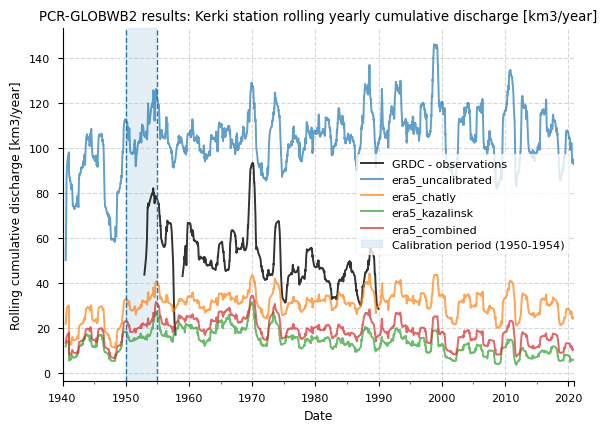

In [25]:
window_days = 365
min_periods = window_days // 2

conversion_factor = 86400 / 1e9  # m3/s to km3/day
grdc_station_kerki_roll_cum = (
    conversion_factor
    * grdc_station_kerki["streamflow"].rolling(time=window_days, min_periods=min_periods).sum().to_series()
)

station_name = "Kerki"
river_kerki1 = aral.River(da.sel(simulation="era5_uncalibrated", station=station_name))
river_kerki2 = aral.River(da.sel(simulation="era5_chatly", station=station_name))
river_kerki3 = aral.River(da.sel(simulation="era5_kazalinsk", station=station_name))
river_kerki4 = aral.River(da.sel(simulation="era5_default", station=station_name))


riv1 =  river_kerki1.Q_raw.rolling(window=window_days, min_periods=min_periods).sum()* conversion_factor
riv2 =  river_kerki2.Q_raw.rolling(window=window_days, min_periods=min_periods).sum()* conversion_factor
riv3 =  river_kerki3.Q_raw.rolling(window=window_days, min_periods=min_periods).sum()* conversion_factor
riv4 =  river_kerki4.Q_raw.rolling(window=window_days, min_periods=min_periods).sum()* conversion_factor


# chatly_era5_roll_cum = conversion_factor * df_combined[("era5", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_cmip_roll_cum = conversion_factor * df_combined[("cmip", "Chatly")].rolling(window=window_days, min_periods=min_periods).sum()
# chatly_no_agri_roll_cum = conversion_factor * df_no_agri["Chatly"].rolling(window=window_days, min_periods=min_periods).sum()

cal_start = pd.Timestamp("1950-01-01")
cal_end = pd.Timestamp("1954-12-31")

plt.figure(figsize=(6, 4.4))
grdc_station_kerki_roll_cum.plot(label="GRDC - observations", color="black", alpha=0.8)
# grdc_station_chatly_roll_cum.plot(label="GRDC - Chatly station", color="gray", alpha=0.8)
riv1.plot( color="tab:blue", alpha=0.7, label="era5_uncalibrated")
riv2.plot( color="tab:orange", alpha=0.7, label="era5_chatly")
riv3.plot( color="tab:green", alpha=0.7, label="era5_kazalinsk")
riv4.plot( color="tab:red", alpha=0.7, label="era5_combined")


plt.axvspan(cal_start, cal_end, color="tab:blue", alpha=0.12, label=f"Calibration period ({cal_start.year}-{cal_end.year})")
plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)
plt.title(f"PCR-GLOBWB2 results: {station_name} station rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc = "center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

In [26]:
import matplotlib.font_manager as fm

[f.name for f in fm.fontManager.ttflist if "Pagella" in f.name]

[]

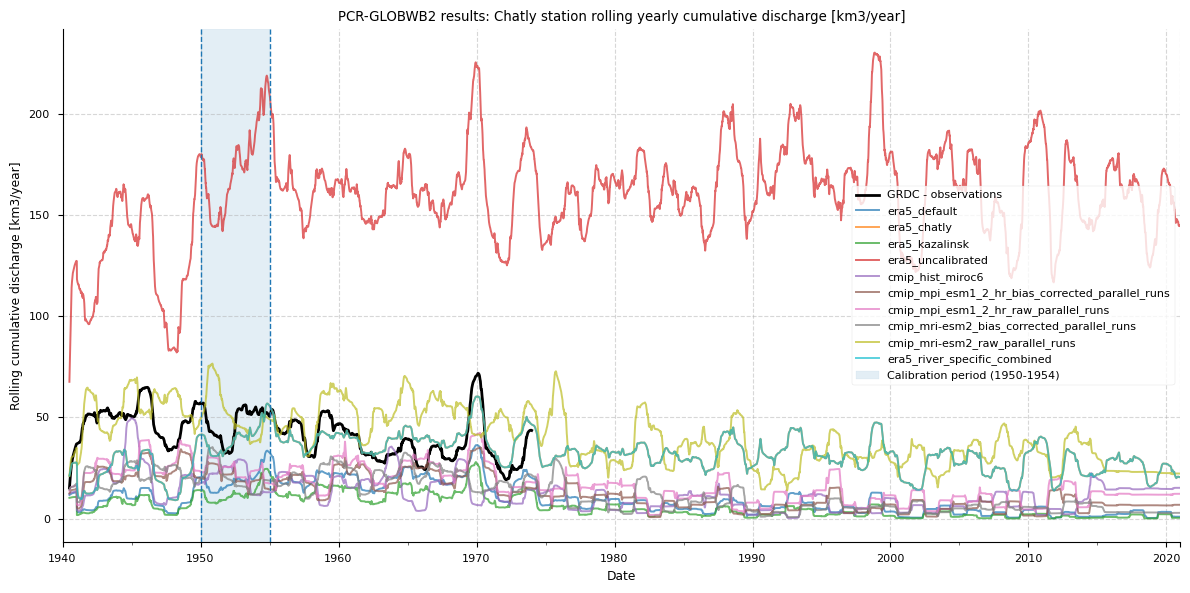

In [27]:
plt.figure(figsize=(12, 6))

# Observations
grdc_station_chatly_roll_cum.plot(
    label="GRDC - observations",
    color="black",
    alpha=1,
    linewidth=2
)

# All model simulations
for sim, rivers_dict in rolled_rivers.items():
    rivers_dict["Amu"].plot(
        label=sim,
        alpha=0.7
    )

# Calibration window
plt.axvspan(
    cal_start,
    cal_end,
    color="tab:blue",
    alpha=0.12,
    label=f"Calibration period ({cal_start.year}-{cal_end.year})"
)

plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)

plt.title("PCR-GLOBWB2 results: Chatly station rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc="center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

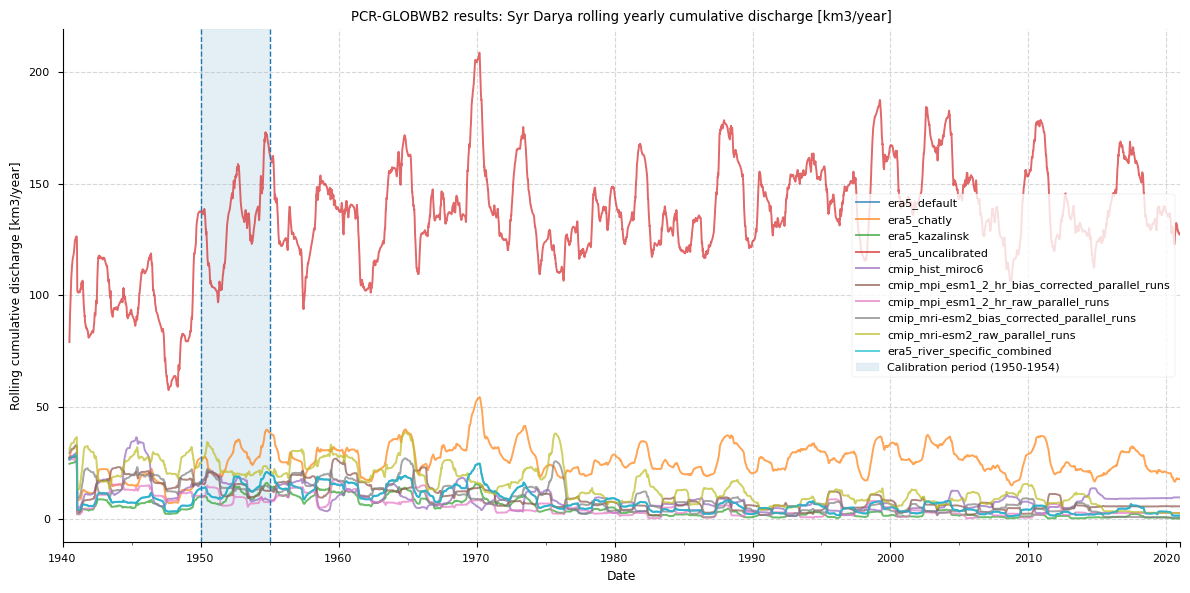

In [28]:
plt.figure(figsize=(12, 6))

# # Observations
# grdc_station_chatly_roll_cum.plot(
#     label="GRDC - observations",
#     color="black",
#     alpha=1,
#     linewidth=2
# )

# All model simulations
for sim, rivers_dict in rolled_rivers.items():
    rivers_dict["Syr"].plot(
        label=sim,
        alpha=0.7
    )

# Calibration window
plt.axvspan(
    cal_start,
    cal_end,
    color="tab:blue",
    alpha=0.12,
    label=f"Calibration period ({cal_start.year}-{cal_end.year})"
)

plt.axvline(cal_start, color="tab:blue", linestyle="--", linewidth=1)
plt.axvline(cal_end, color="tab:blue", linestyle="--", linewidth=1)

plt.title("PCR-GLOBWB2 results: Syr Darya rolling yearly cumulative discharge [km3/year]")
plt.xlabel("Date")
plt.ylabel("Rolling cumulative discharge [km3/year]")
plt.legend(loc="center right")
plt.grid(alpha=0.5, linestyle="--")
plt.tight_layout()

In [29]:
importlib.reload(aral)

nachtnebel = pd.read_csv(
    Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/Nachtnebel_table.csv"),
    sep=";",
    decimal=",",
)

nachtnebel["Year"] = nachtnebel["Year"].astype(int)
nachtnebel = nachtnebel.set_index("Year")


In [30]:
# importlib.reload(aral)

# Amu_chatly = aral.River(df, q_col="Chatly", name="Amu Darya - Chatly")
# Amu_kerki = aral.River(df, q_col="Kerki", name="Amu Darya - Kerki")
# Syr_kaza = aral.River(df, q_col="Kazalinsk", name="Syr Darya - Kazalinsk")
# # Syr_kara = aral.River(df, q_col="Karaozek", name="Syr Darya - Karaozek")
# Syr_tyumen = aral.River(df, q_col="Tyumen-Aryk", name="Syr Darya - Tyumen Aryk")



# fig1 = Amu_kerki.plot_yearly(
#     return_fig=True,
#     observations=nachtnebel["Amudarya_Q"],
#     observation_label="Nachtnebel Amudarya_Q",
#     )
# fig2 = Amu_chatly.plot_yearly(
#     return_fig=True,
#     observations=nachtnebel["Amudarya_Q"],
#     observation_label="Observations", 
#     )

# fig3 = Syr_kaza.plot_yearly(return_fig=True,
#                             observations=nachtnebel["Syrdarya_Q"],
#     observation_label="Observations",
#     )
# import os

# os.makedirs("figures", exist_ok=True)
# fig1.savefig("figures/Amu_kerki_yearly_discharge.pdf", bbox_inches="tight")
# fig2.savefig("figures/Amu_chatly_yearly_discharge.pdf", bbox_inches="tight")
# fig3.savefig("figures/Syr_kaza_yearly_discharge.pdf", bbox_inches="tight")

In [31]:
# Syr_kaza.plot_yearly()

In [32]:
aral_meteo = xr.open_dataset(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc"
)

# Initial settings
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"

# Run the model

def run_sim(sim_name, rivers_dict):
    return aral.run_connected_aral_model(
        aral_meteo,
        rivers=[rivers_dict["Amu"], rivers_dict["Syr"]],
        ahv_csv=ahv_file,
        V0_km3=initial_volume,
        start_time="1950-01-01",
        end_time="2014-12-31",
        tqdm_position=1,
    )


results = {
    sim: run_sim(sim, rivers_dict)
    for sim, rivers_dict in rivers.items()
}

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/23740 [00:00<?, ?it/s]

Found 1 NetCDF files in /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/dahiti


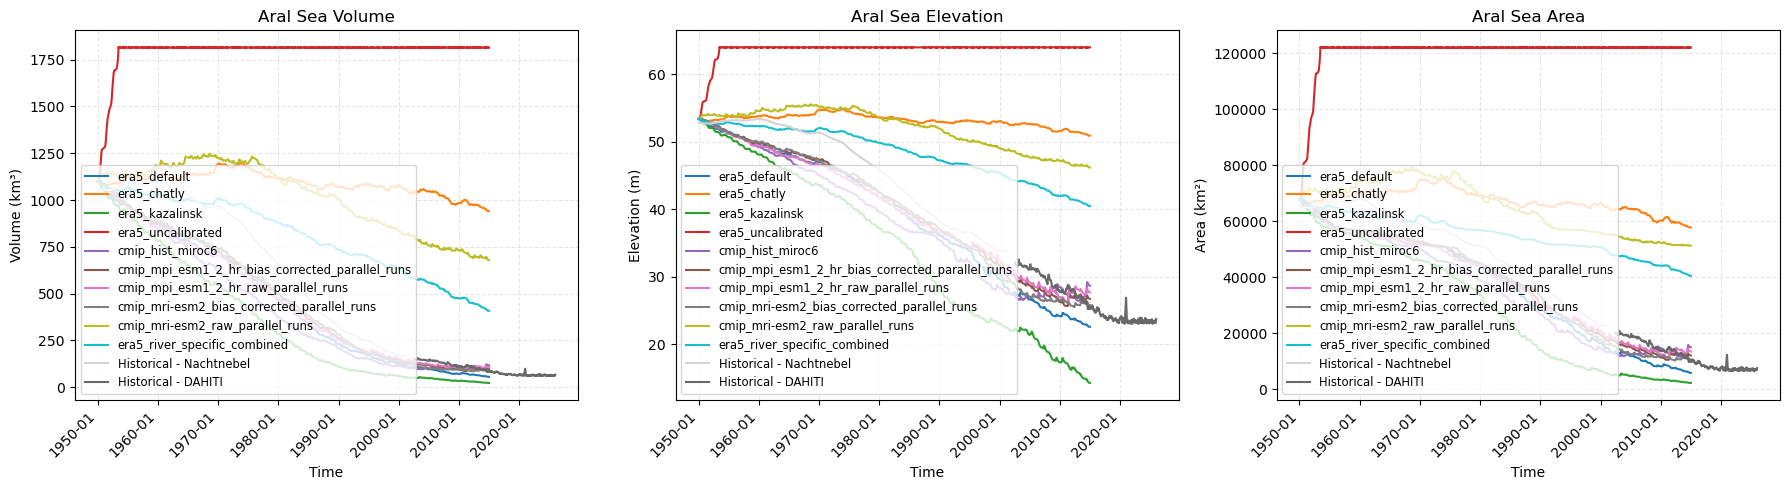

In [25]:
importlib.reload(aral)
observation = aral.make_obs()
aral.plot_aral_results(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
    
)

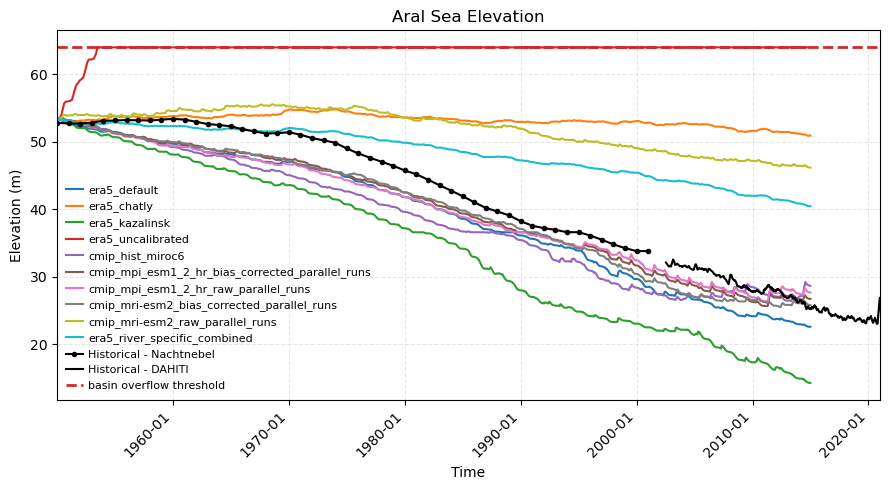

In [26]:
importlib.reload(aral)
aral.plot_aral_elevation(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
)

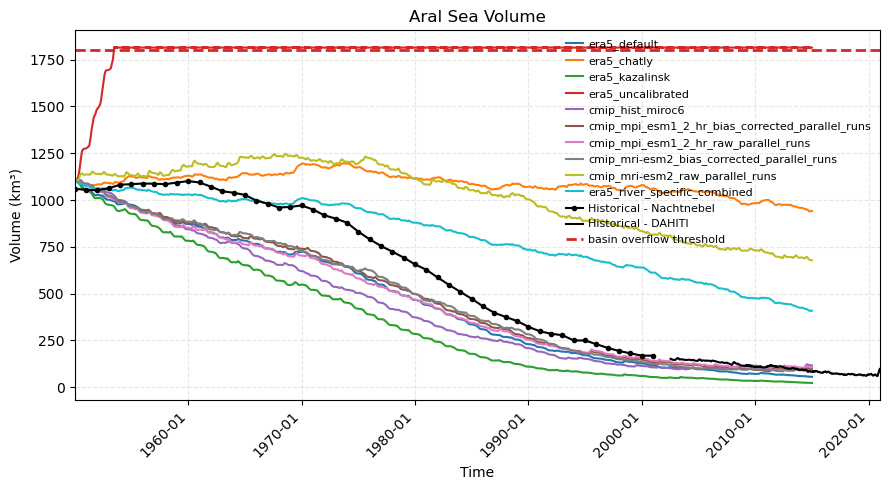

In [27]:
importlib.reload(aral)
test_save = aral.plot_aral_volume(
    list(results.values()),
    labels=list(results.keys()),
    observations=observation,
)

test_save.savefig("figures/aral_volume_comparison.png", bbox_inches="tight")

In [28]:
observation

[(         time  elevation_m
  0  1950-01-01        52.82
  1  1951-01-01        52.72
  2  1952-01-01        52.70
  3  1953-01-01        52.86
  4  1954-01-01        53.12
  5  1955-01-01        53.16
  6  1956-01-01        53.22
  7  1957-01-01        53.19
  8  1958-01-01        53.16
  9  1959-01-01        53.28
  10 1960-01-01        53.40
  11 1961-01-01        53.29
  12 1962-01-01        52.97
  13 1963-01-01        52.63
  14 1964-01-01        52.49
  15 1965-01-01        52.30
  16 1966-01-01        51.87
  17 1967-01-01        51.56
  18 1968-01-01        51.23
  19 1969-01-01        51.28
  20 1970-01-01        51.41
  21 1971-01-01        51.06
  22 1972-01-01        50.55
  23 1973-01-01        50.22
  24 1974-01-01        49.86
  25 1975-01-01        49.01
  26 1976-01-01        48.27
  27 1977-01-01        47.64
  28 1978-01-01        47.05
  29 1979-01-01        46.45
  30 1980-01-01        45.75
  31 1981-01-01        45.19
  32 1982-01-01        44.39
  33 1983-01-0

In [29]:
# df_aral_no_agri = aral.run_connected_aral_model(
#     aral_meteo,
#     rivers=[Amu_chatly_no_agri, Syr_kaza_no_agri],
#     ahv_csv=ahv_file,
#     V0_km3=initial_volume,
#     start_time="1950-01-01",
#     end_time="2020-12-31",
#     tqdm_position=1,
# )

In [30]:
# observation = aral.make_obs()

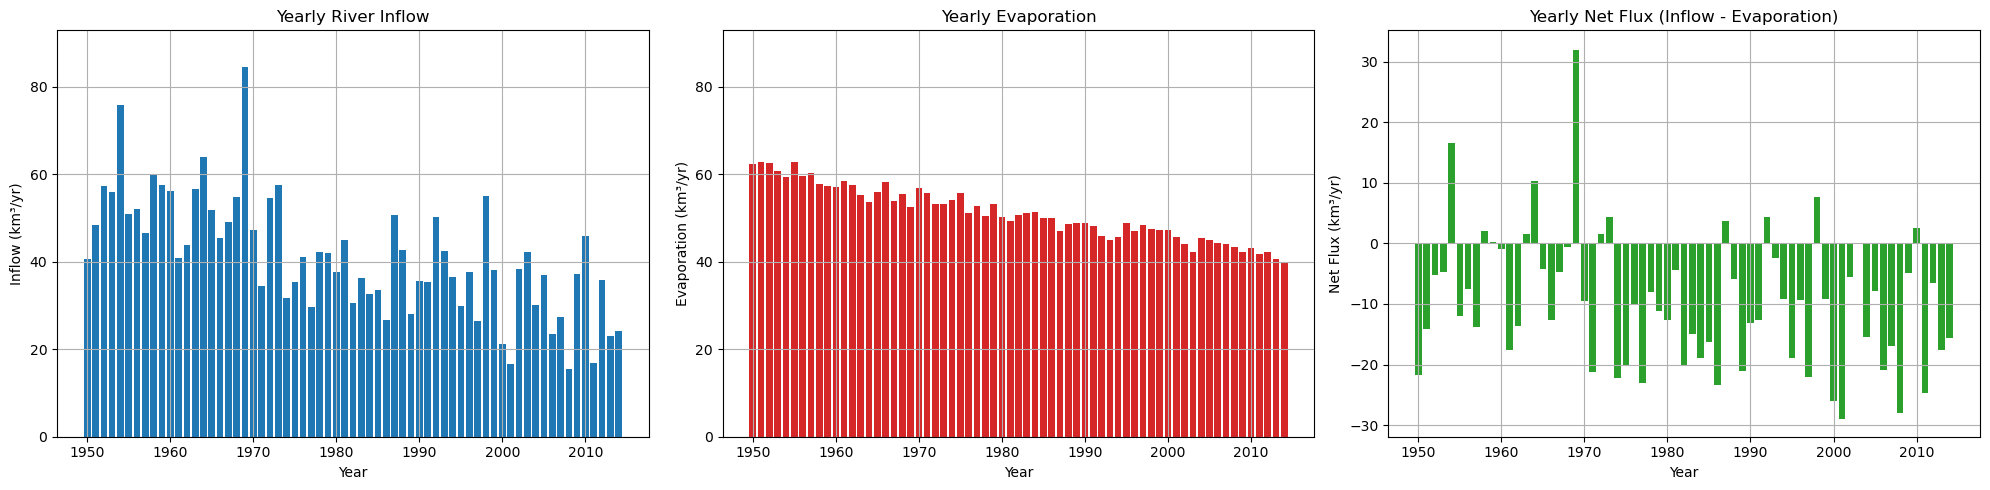

In [31]:
aral.plot_aral_fluxes(results['era5_river_specific_combined'])

In [32]:
import numpy as np

def arcdeg_to_km(lat, dlat=1.0, dlon=1.0):
    """
    Convert arc-degree grid spacing to km at a given latitude.

    Parameters
    ----------
    lat : float
        Latitude in degrees
    dlat : float
        Latitude spacing in degrees
    dlon : float
        Longitude spacing in degrees

    Returns
    -------
    dlat_km : float
        North-south distance in km
    dlon_km : float
        East-west distance in km at given latitude
    """

    R = 6371.0  # Earth radius in km

    # 1 degree latitude is constant everywhere
    km_per_deg_lat = (np.pi / 180) * R

    # 1 degree longitude depends on latitude
    km_per_deg_lon = km_per_deg_lat * np.cos(np.deg2rad(lat))

    return dlat * km_per_deg_lat, dlon * km_per_deg_lon

In [33]:
lat = 55

dlat_km, dlon_km = arcdeg_to_km(lat)

print(dlat_km, dlon_km)

111.19492664455873 63.77878976510199


In [34]:
KarakumCanal = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/karakum/KarakumCanal.csv"
pd.read_csv(KarakumCanal, delimiter=";")

,year,km3,m3s
0,1950,0,0
1,1951,"0,2051244",0
2,1952,"0,4102488",0
3,1953,"0,6153732",0
4,1954,"0,8204976",0
...,...,...,...
69,2019,"12,307464",650
70,2020,"12,307464",650
71,2021,"12,307464",650
72,2022,"12,307464",650


In [35]:
ds

<xarray.Dataset> Size: 53MB
Dimensions:     (simulation: 9, time: 29586, station: 50)
Coordinates:
  * simulation  (simulation) <U47 2kB 'era5_default' ... 'cmip_mri-esm2_raw_p...
  * time        (time) datetime64[ns] 237kB 1940-01-01 1940-01-02 ... 2020-12-31
    lat         (station) float32 200B ...
    lon         (station) float32 200B ...
  * station     (station) <U14 3kB 'Tyumen-aryk' 'Kazalinsk' ... 'Obizarang'
Data variables:
    discharge   (simulation, time, station) float32 53MB ...

In [36]:
da_test = ds["discharge"].sel(simulation="era5_default", station="Chatly", time=slice("1958-01-01", "1960-12-31"))
da_kerki = ds["discharge"].sel(simulation="era5_default", station="Kerki", time=slice("1958-01-01", "1960-12-31"))


time = da_test.time
year = time.dt.year
doy = time.dt.dayofyear
doy = xr.where(doy > 365, 365, doy)  # leap year safety

years = np.unique(year)
year_map = xr.DataArray(
    {
        1958: 100,
        1959: 300,
        1960: 350
    }
)

year_map = xr.DataArray(
    [100, 200, 300, 350],
    coords={"year": [1958, 1959, 1960, 1961]},
    dims="year"
)
yearly_change = year_map.sel(year=time.dt.year)
#yearly_change = 300


A = 0.9*yearly_change
mean = yearly_change

time = da_test.time

year = time.dt.year
doy = time.dt.dayofyear

doy = xr.where(doy > 365, 365, doy)

year_map = xr.DataArray(
    [100, 300, 350],
    coords={"year": [1958, 1959, 1960]},
    dims="year"
)

yearly_total = year_map.sel(year=year)

seasonal_offset = mean + A * np.sin(2*np.pi*(doy - 1)/365 - np.pi/2)
season = 0.5 * (1 - np.cos(2 * np.pi * (doy - 1) / 365))
season = (0.5 * (1 - np.cos(2*np.pi*(doy - 1)/365)))**1.5
irrigation = yearly_total * season

da_test_karakum = da_test - seasonal_offset
#da_test_karakum = da_test - irrigation

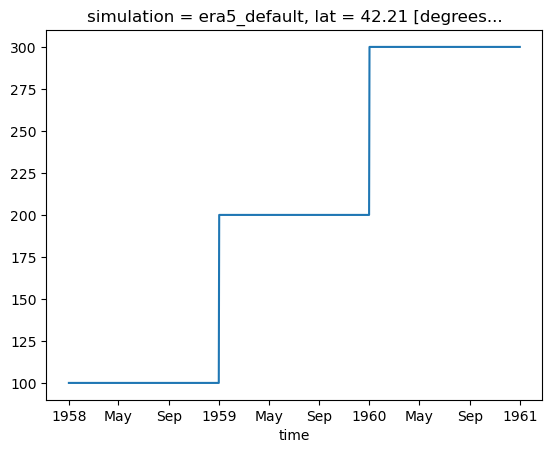

In [37]:
yearly_change.plot()

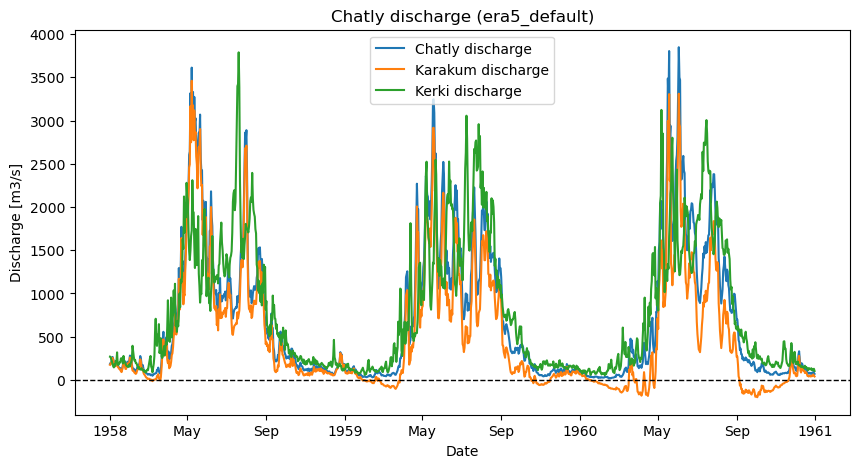

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
da_test.plot(ax=ax, label="Chatly discharge")
da_test_karakum.plot(ax=ax, label="Karakum discharge")
da_kerki.plot(ax=ax, label="Kerki discharge")


ax.set_title("Chatly discharge (era5_default)")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m3/s]")   
ax.legend()
ax.axhline(0, color="black", linestyle="--", linewidth=1)




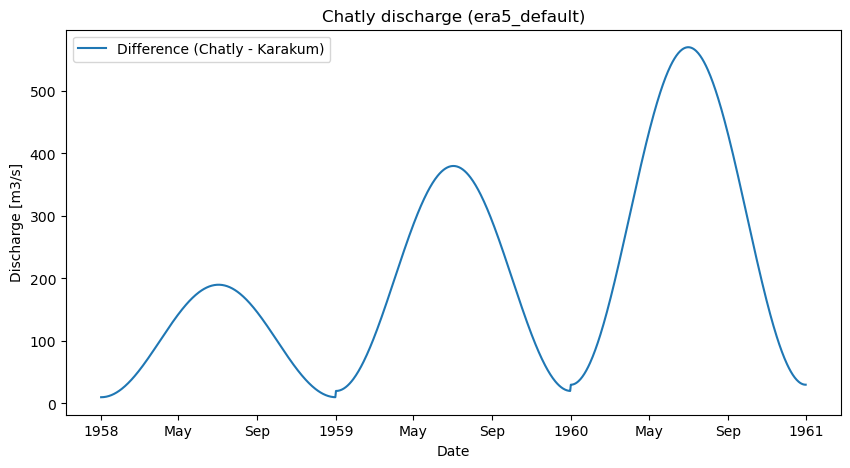

In [39]:
difference = da_test - da_test_karakum

fig, ax = plt.subplots(figsize=(10, 5))
difference.plot(ax=ax, label="Difference (Chatly - Karakum)")

ax.set_title("Chatly discharge (era5_default)")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge [m3/s]")   
ax.legend()


In [40]:
yearly_mean = difference.groupby("time.year").mean("time")

In [41]:
yearly_mean

<xarray.DataArray (year: 3)> Size: 24B
array([100.        , 200.        , 299.26240438])
Coordinates:
    simulation  <U47 188B 'era5_default'
    lat         float32 4B 42.21
    lon         float32 4B 60.21
    station     <U14 56B 'Chatly'
  * year        (year) int64 24B 1958 1959 1960

In [42]:
shape = (1 - np.cos(2*np.pi*(doy - 1)/365)) / 2
shape = shape**1.2  # mild skew
shape = shape / shape.groupby(time.dt.year).mean("time")

In [43]:
shape

<xarray.DataArray 'dayofyear' (time: 1096, year: 3)> Size: 26kB
array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.37646482e-05, 2.37646482e-05, 2.38297553e-05],
       [1.25419415e-04, 1.25419415e-04, 1.25763022e-04],
       ...,
       [1.25419415e-04, 1.25419415e-04, 1.25763022e-04],
       [2.37646482e-05, 2.37646482e-05, 2.38297553e-05],
       [2.37646482e-05, 2.37646482e-05, 2.38297553e-05]])
Coordinates:
    simulation  <U47 188B 'era5_default'
  * time        (time) datetime64[ns] 9kB 1958-01-01 1958-01-02 ... 1960-12-31
    lat         float32 4B 42.21
    lon         float32 4B 60.21
    station     <U14 56B 'Chatly'
  * year        (year) int64 24B 1958 1959 1960

In [44]:


karakum_df = pd.read_csv(KarakumCanal, sep=";", decimal=",")
karakum_df["time"] = pd.to_datetime(karakum_df["year"], format="%Y")
karakum_q_series = karakum_df.set_index("time")["m3s"].resample("D").interpolate("time")
karakum = aral.River(-karakum_q_series, name="Karakum Canal", scaling=0.6)
karakum_07 = aral.River(-karakum_q_series, name="Karakum Canal", scaling=0.7)


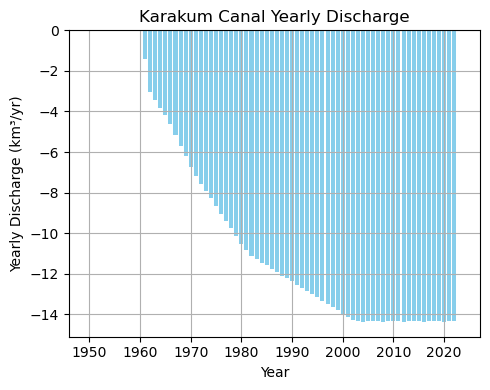

In [45]:
karakum_07.plot_yearly()


In [46]:
rivers["test_karakum_hack"] = {
    "Amu": rivers["era5_chatly"]["Amu"],
    "Syr": rivers["era5_default"]["Syr"],
    "Canal": karakum
}


rivers["test_karakum_hack_full_chatly"] = {
    "Amu": rivers["era5_chatly"]["Amu"],
    "Syr": rivers["era5_kazalinsk"]["Syr"],
    "Canal": karakum_07
}


In [47]:

result_karakum = aral.run_connected_aral_model(
    aral_meteo,
    rivers=list(rivers["test_karakum_hack"].values()),
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
    tqdm_position=1,
)



result_karakum_2 = aral.run_connected_aral_model(
    aral_meteo,
    rivers=list(rivers["test_karakum_hack_full_chatly"].values()),
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31",
    tqdm_position=1,
)

Simulating Aral Sea volume balance:   0%|          | 0/25932 [00:00<?, ?it/s]

Simulating Aral Sea volume balance:   0%|          | 0/25932 [00:00<?, ?it/s]

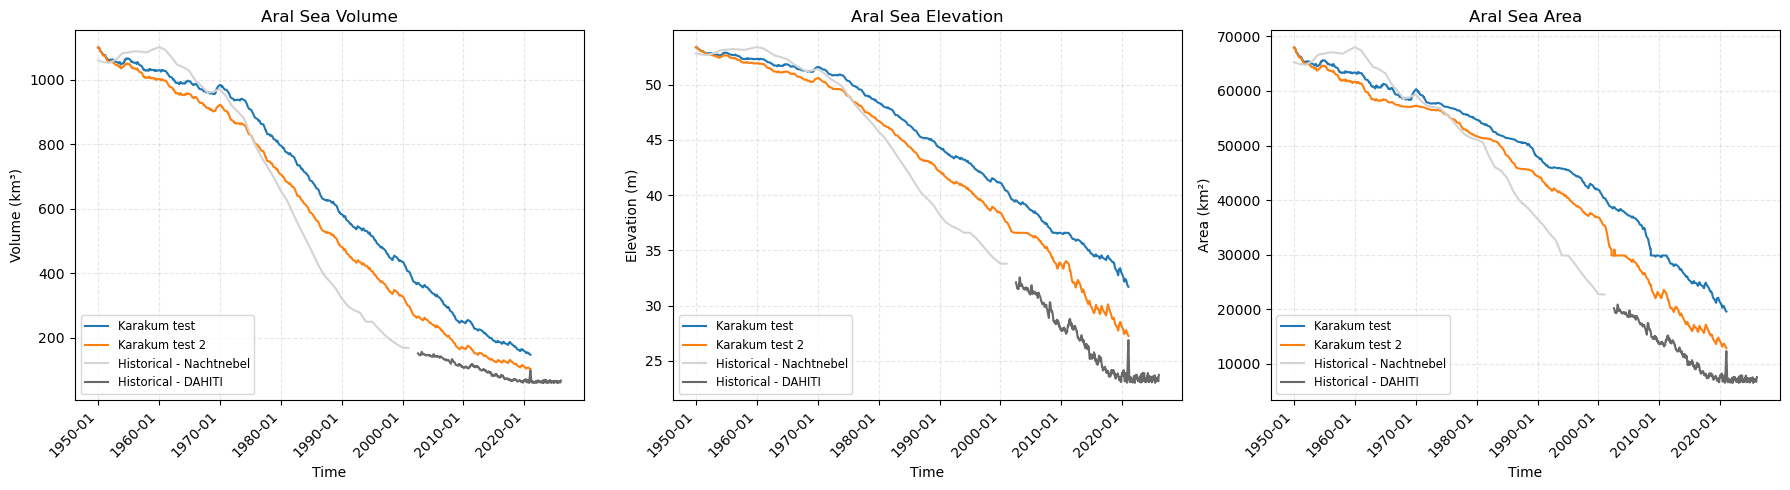

In [48]:
aral.plot_aral_results(
    [result_karakum, result_karakum_2],
    labels=["Karakum test", "Karakum test 2"],
    observations=observation,
)

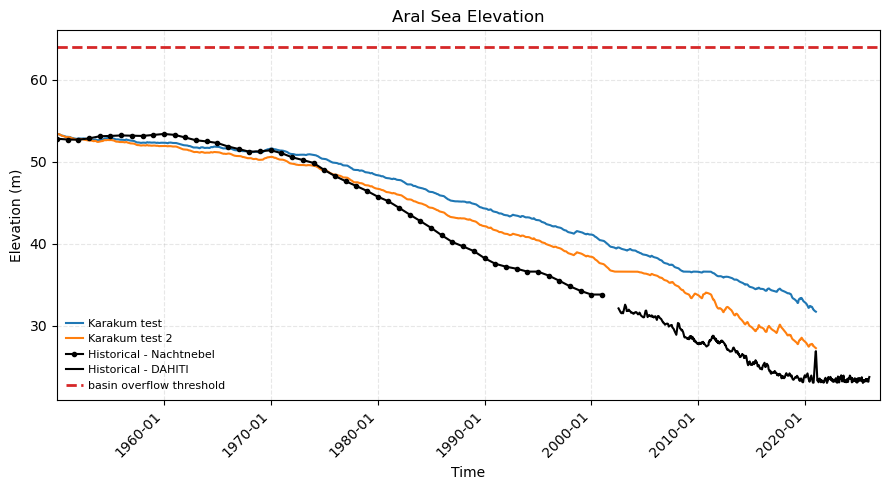

In [49]:
aral.plot_aral_elevation(
    [result_karakum, result_karakum_2],
    labels=["Karakum test", "Karakum test 2"],
    observations=observation,
)

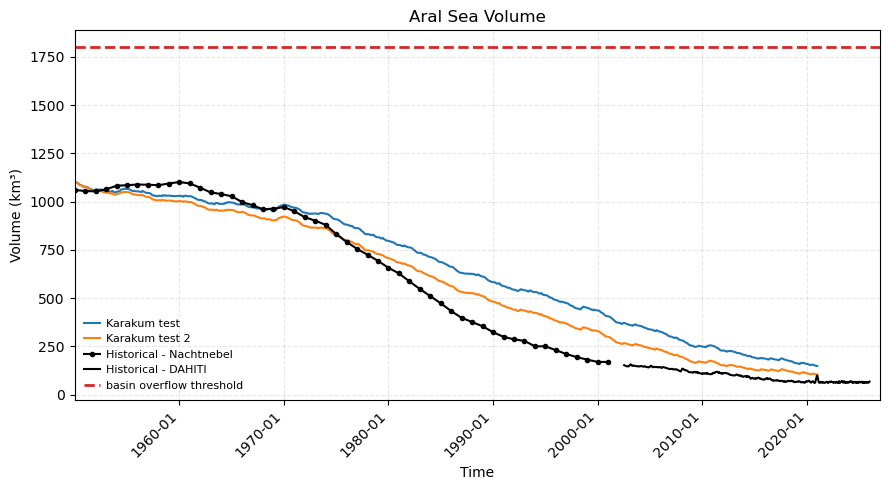

In [50]:
aral.plot_aral_volume(
    [result_karakum, result_karakum_2],
    labels=["Karakum test", "Karakum test 2"],
    observations=observation,
);